In [14]:
import pandas as pd
import re

markdown_string = """
| TokenMixer           | Kernel Size | ImageWoof              | PathMNIST              | DermaMNIST             | PneumoniaMNIST         | OrganSMNIST            |
|-----------------------|-------------|------------------------|------------------------|------------------------|------------------------|------------------------|
| pooling               | 3           | 0.8501, 0.9645, 0.8531 | 0.8643, 0.9596, 0.8539 | 0.7585, 0.9064, 0.7737 | 0.9321, 0.983, 0.9421  | 0.762, 0.9536, 0.7657  |
|                       | 5           | 0.861, 0.9641, 0.8637  | 0.8726, 0.9651, 0.8647 | 0.7232, 0.9191, 0.7625 | 0.9521, 0.9883, 0.9584 | 0.7632, 0.9618, 0.7648 |
|                       | 7           | 0.8612, 0.9697, 0.8633 | 0.8914, 0.975, 0.8869  | 0.7789, 0.9198, 0.8058 | 0.9423, 0.9793, 0.9496 | 0.7725, 0.9475, 0.775  |
| conv                  | 3           | 0.8494, 0.968, 0.8524  | 0.8768, 0.9564, 0.8687 | 0.7523, 0.9127, 0.7624 | 0.9444, 0.9832, 0.9513 | 0.7889, 0.9545, 0.7908 |
|                       | 5           | 0.8361, 0.9563, 0.8383 | 0.8818, 0.9678, 0.8705 | 0.7642, 0.9132, 0.7894 | 0.9372, 0.9861, 0.9459 | 0.7963, 0.9609, 0.7967 |
|                       | 7           | 0.8259, 0.9607, 0.8256 | 0.8684, 0.9721, 0.857  | 0.7863, 0.9143, 0.7818 | 0.9517, 0.988, 0.9568  | 0.774, 0.9567, 0.7794  |
| grouped conv              | 3           | 0.8491, 0.9642, 0.8521 | 0.8601, 0.962, 0.8475  | 0.774, 0.9, 0.7936     | 0.9487, 0.9906, 0.9549 | 0.7818, 0.944, 0.7831  |
|                       | 5           | 0.8308, 0.9556, 0.8338 | 0.8977, 0.9641, 0.8949 | 0.7594, 0.9046, 0.7928 | 0.9598, 0.9918, 0.9654 | 0.7916, 0.9545, 0.7973 |
|                       | 7           | 0.8375, 0.9831, 0.84   | 0.8967, 0.98, 0.8919   | 0.7605, 0.9014, 0.7916 | 0.9214, 0.9864, 0.933  | 0.791, 0.9438, 0.7965  |
| local attn               | 3           | 0.8735, 0.9671, 0.8753 | 0.8856, 0.9745, 0.8775 | 0.7737, 0.9097, 0.7923 | 0.9321, 0.9801, 0.9421 | 0.7747, 0.9489, 0.779  |
|                       | 5           | 0.8614, 0.9654, 0.8619 | 0.8852, 0.9742, 0.8786 | 0.7631, 0.9043, 0.7613 | 0.9513, 0.9935, 0.9552 | 0.7728, 0.9568, 0.779  |
|                       | 7           | 0.8679, 0.9666, 0.8697 | 0.8868, 0.9736, 0.8784 | 0.7577, 0.9197, 0.7738 | 0.9513, 0.9755, 0.9583 | 0.7617, 0.9554, 0.7667 |
| local attn (warm start)  | 3           | 0.8742, 0.9723, 0.8759 | 0.8918, 0.9753, 0.8876 | 0.7899, 0.903, 0.7995  | 0.9607, 0.9814, 0.9654 | 0.7769, 0.9582, 0.7814 |
|                       | 5           | 0.8841, 0.9904, 0.8875 | 0.8884, 0.9729, 0.8829 | 0.7879, 0.9032, 0.8035 | 0.9632, 0.9913, 0.9688 | 0.7921, 0.9449, 0.7956 |
|                       | 7           | 0.8834, 0.9919, 0.8841 | 0.8991, 0.9796, 0.8931 | 0.7778, 0.9028, 0.7895 | 0.9436, 0.9894, 0.9482 | 0.7862, 0.9624, 0.7918 |
| global attn              | -           | 0.8641, 0.9646, 0.8662 | 0.8995, 0.9799, 0.8962 | 0.7451, 0.9046, 0.7714 | 0.9286, 0.9887, 0.9386 | 0.7667, 0.9512, 0.7732 |
| global attn (warm start) | -           | 0.8908, 0.992, 0.8939  | 0.9011, 0.9847, 0.899  | 0.7672, 0.9067, 0.7821 | 0.9444, 0.9915, 0.9513 | 0.7792, 0.9314, 0.785  |
| identity              | 1           | 0.8597, 0.984, 0.8604  | 0.7985, 0.9511, 0.7792 | 0.8056, 0.9646, 0.8077 | 0.9291, 0.9911, 0.9402 | 0.7658, 0.9574, 0.7695 |
| ResNet18              | 3           | 0.8968, 0.9875, 0.8989 | 0.8976, 0.9871, 0.89   | 0.8071, 0.9476, 0.8227 | 0.8974, 0.939, 0.9139  | 0.792, 0.9558, 0.7955  |
"""

lines = markdown_string.split("\n")
header = lines[1].strip("|").split("|")
header = list(map(lambda s: s.strip(), header))

data = []

# Loop through lines starting from 2
for line in lines[3:]:

    # Break once we hit an empty line
    if not line.strip():
        break

    cols = line.strip("|").split("|")
    cols = map(lambda s: s.strip(), cols)
    row = dict(zip(header, cols))
    data.append(row)

df = pd.DataFrame(data)
df.iloc[:, 0] = df.iloc[:, 0].replace("", pd.NA).ffill()
df.set_index(['TokenMixer', 'Kernel Size'], inplace=True)

df_split = df.apply(lambda col: col.str.split(","))
df_expanded = pd.concat(
    [df_split[col].apply(pd.Series).add_prefix(f"{col.strip()}_") for col in df_split.columns],
    axis=1
)

suffix_map = {
    "_0": "_acc",
    "_1": "_auc",
    "_2": "_f1"
}
df = df_expanded.rename(columns=lambda col: next((col.replace(k, v) for k, v in suffix_map.items() if k in col), col))
df = df.apply(pd.to_numeric, errors="coerce")
# df.to_pickle('classification_2p2t_finetuned.pkl')

# drop resnet and other metrics
df_rank = df.loc[~df.index.get_level_values(0).str.startswith('ResNet'), df.columns.str.endswith('_auc')]
df_rank = df_rank.rank(axis=0, ascending=False, method="first")
df_rank_no_imgwoof = df_rank.iloc[:, 1:]

df_rank


ImageWoof_auc  PathMNIST_auc  \
TokenMixer               Kernel Size                                 
pooling                  3                     13.0           16.0   
                         5                     15.0           13.0   
                         7                      7.0            6.0   
conv                     3                      8.0           17.0   
                         5                     17.0           12.0   
                         7                     16.0           11.0   
grouped conv             3                     14.0           15.0   
                         5                     18.0           14.0   
                         7                      5.0            2.0   
local attn               3                      9.0            7.0   
                         5                     11.0            8.0   
                         7                     10.0            9.0   
local attn (warm start)  3                      6.0            5.0   
                         5                      3.0           10.0   
                         7                      2.0            4.0   
global attn              -                     12.0            3.0   
global attn (warm start) -                      1.0            1.0   
identity                 1                      4.0           18.0   

                                      DermaMNIST_auc  PneumoniaMNIST_auc  \
TokenMixer               Kernel Size                                       
pooling                  3                      10.0                14.0   
                         5                       4.0                 9.0   
                         7                       2.0                17.0   
conv                     3                       7.0                13.0   
                         5                       6.0                12.0   
                         7                       5.0                10.0   
grouped conv             3                      18.0                 6.0   
                         5                      11.0                 2.0   
                         7                      17.0                11.0   
local attn               3                       8.0                16.0   
                         5                      13.0                 1.0   
                         7                       3.0                18.0   
local attn (warm start)  3                      15.0                15.0   
                         5                      14.0                 4.0   
                         7                      16.0                 7.0   
global attn              -                      12.0                 8.0   
global attn (warm start) -                       9.0                 3.0   
identity                 1                       1.0                 5.0   

                                      OrganSMNIST_auc  
TokenMixer               Kernel Size                   
pooling                  3                       11.0  
                         5                        2.0  
                         7                       14.0  
conv                     3                        9.0  
                         5                        3.0  
                         7                        7.0  
grouped conv             3                       16.0  
                         5                       10.0  
                         7                       17.0  
local attn               3                       13.0  
                         5                        6.0  
                         7                        8.0  
local attn (warm start)  3                        4.0  
                         5                       15.0  
                         7                        1.0  
global attn              -                       12.0  
global attn (warm start) -                       18.0  
identity                 1                        5.

# Global Rank

In [15]:
df_rank.mean(1).sort_values()

TokenMixer                Kernel Size
local attn (warm start)   7               6.0
global attn (warm start)  -               6.4
identity                  1               6.6
local attn                5               7.8
pooling                   5               8.6
local attn (warm start)   3               9.0
                          5               9.2
pooling                   7               9.2
global attn               -               9.4
local attn                7               9.6
conv                      7               9.8
                          5              10.0
grouped conv              7              10.4
local attn                3              10.6
conv                      3              10.8
grouped conv              5              11.0
pooling                   3              12.8
grouped conv              3              13.8
dtype: float64

In [16]:
df_rank_no_imgwoof.mean(1).sort_values()

TokenMixer                Kernel Size
pooling                   5               7.00
local attn                5               7.00
local attn (warm start)   7               7.00
identity                  1               7.25
global attn (warm start)  -               7.75
conv                      5               8.25
                          7               8.25
global attn               -               8.75
grouped conv              5               9.25
local attn                7               9.50
local attn (warm start)   3               9.75
pooling                   7               9.75
local attn (warm start)   5              10.75
local attn                3              11.00
conv                      3              11.50
grouped conv              7              11.75
pooling                   3              12.75
grouped conv              3              13.75
dtype: float64

# Pool Size ranking

In [17]:
df_rank.groupby('Kernel Size').mean()

,ImageWoof_auc,PathMNIST_auc,DermaMNIST_auc,PneumoniaMNIST_auc,OrganSMNIST_auc
Kernel Size,,,,,
-,6.5,2.0,10.5,5.5,15.0
1,4.0,18.0,1.0,5.0,5.0
3,10.0,12.0,11.6,12.8,10.6
5,12.8,11.4,9.6,5.6,7.2
7,8.0,6.4,8.6,12.6,9.4


In [18]:
df_rank.groupby('Kernel Size').mean().mean(1).sort_values()

Kernel Size
1     6.60
-     7.90
7     9.00
5     9.32
3    11.40
dtype: float64

In [19]:
df_rank_no_imgwoof.groupby('Kernel Size').mean().mean(1).sort_values()

Kernel Size
1     7.25
-     8.25
5     8.45
7     9.25
3    11.75
dtype: float64

# Token Mixer

In [20]:
df_rank.groupby('TokenMixer').mean()

,ImageWoof_auc,PathMNIST_auc,DermaMNIST_auc,PneumoniaMNIST_auc,OrganSMNIST_auc
TokenMixer,,,,,
conv,13.666667,13.333333,6.000000,11.666667,6.333333
global attn,12.000000,3.000000,12.000000,8.000000,12.000000
global attn (warm start),1.000000,1.000000,9.000000,3.000000,18.000000
grouped conv,12.333333,10.333333,15.333333,6.333333,14.333333
identity,4.000000,18.000000,1.000000,5.000000,5.000000
local attn,10.000000,8.000000,8.000000,11.666667,9.000000
local attn (warm start),3.666667,6.333333,15.000000,8.666667,6.666667
pooling,11.666667,11.666667,5.333333,13.333333,9.000000


In [21]:
df_rank.groupby('TokenMixer').mean().mean(1).sort_values()

TokenMixer
global attn (warm start)     6.400000
identity                     6.600000
local attn (warm start)      8.066667
local attn                   9.333333
global attn                  9.400000
conv                        10.200000
pooling                     10.200000
grouped conv                11.733333
dtype: float64

In [22]:
df_rank_no_imgwoof.groupby('TokenMixer').mean().mean(1).sort_values()

TokenMixer
identity                     7.250000
global attn (warm start)     7.750000
global attn                  8.750000
local attn                   9.166667
local attn (warm start)      9.166667
conv                         9.333333
pooling                      9.833333
grouped conv                11.583333
dtype: float64

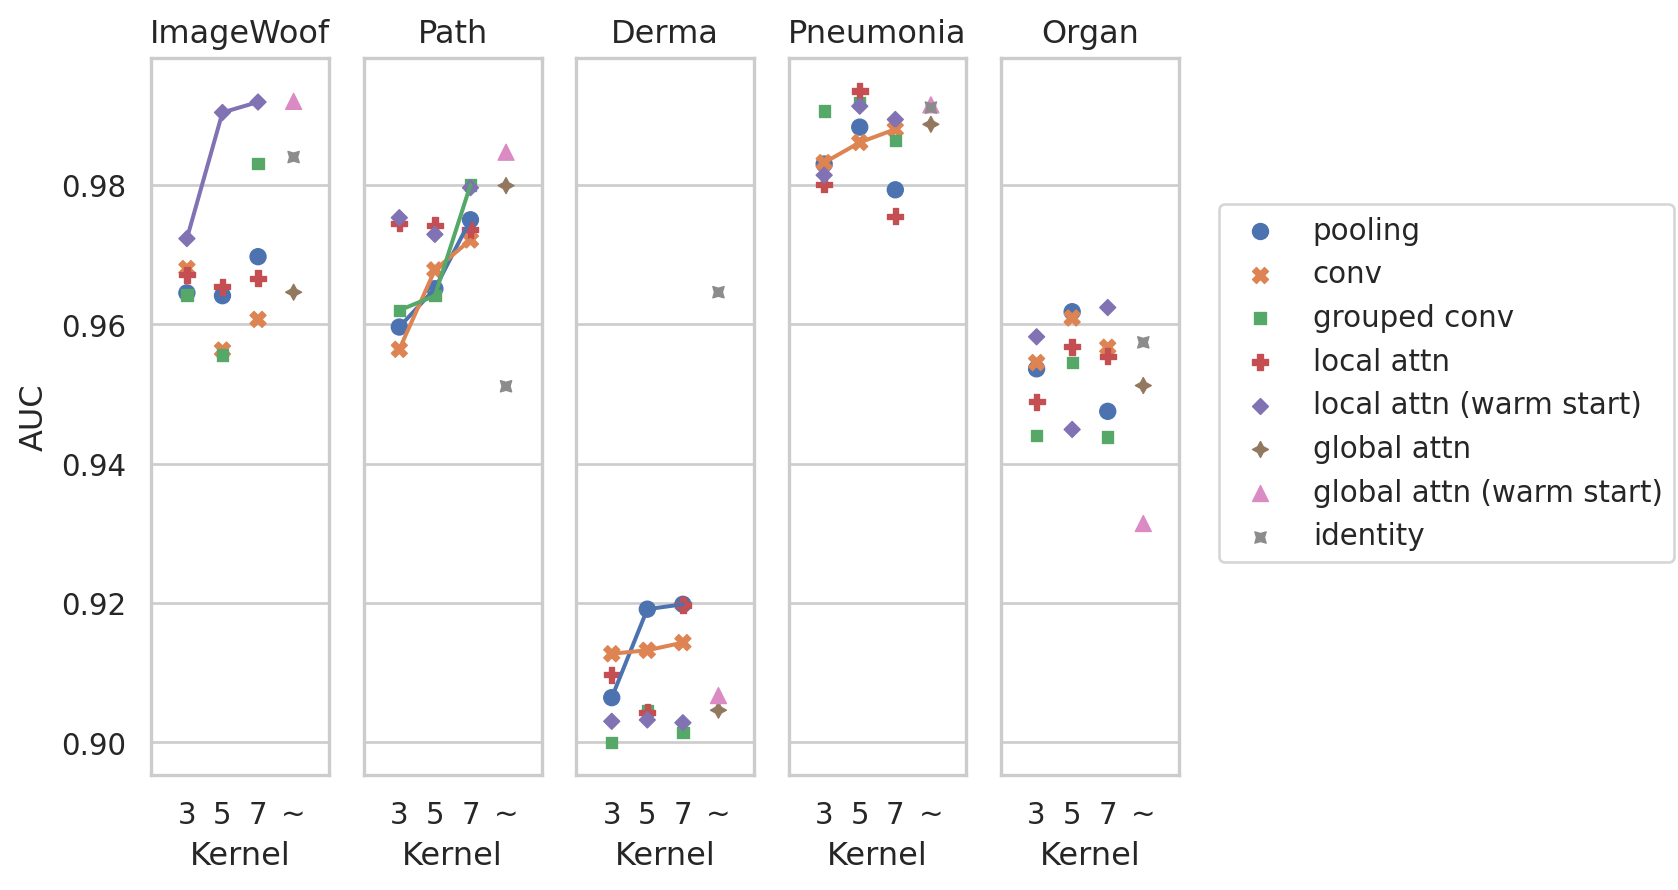

In [23]:
import seaborn as sns
from seaborn import objects as so

df_long = df.loc[:, df.columns.str.endswith('_auc')]
df_long.columns = df_long.columns.str.rstrip('_auc')
df_long.columns = df_long.columns.str.rstrip('MNIST')
df_long = df_long.loc[~df.index.get_level_values(0).str.startswith('ResNet'), :]
df_long = df_long.reset_index().melt(id_vars=["TokenMixer", "Kernel Size"], var_name="dataset", value_name="auc")
df_long.loc[df_long['Kernel Size'].isin(['1', '-']), 'Kernel Size'] = '~'

df_lines = df_long.query(' or '.join([
    "dataset == 'ImageWoof' and TokenMixer.isin(['local attn (warm start)'])",
    "dataset == 'Path' and TokenMixer.isin(['pooling', 'conv', 'grouped conv'])",
    "dataset == 'Derma' and TokenMixer.isin(['conv', 'pooling'])",
    "dataset == 'Pneumonia' and TokenMixer.isin(['conv'])",
]))

(
    so.Plot(df_long, x="Kernel Size", y="auc", color="TokenMixer")
    .facet(col="dataset")
    .theme(sns.axes_style("whitegrid"))
    .add(so.Line(), legend=False, data=df_lines)
    .add(so.Dot(), marker='TokenMixer')
    .limit(x=(-1, 4))
    .layout(engine='tight')
    .label(x='Kernel', y='AUC', color='')
    .save(f'2p2t_pretraining.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
)

In [24]:
from matplotlib import pyplot as plt
sns.scatterplot(df_rank_no_imgwoof.mean(1).rename('rank').reset_index(), x='Kernel Size', y='rank', hue='Token Mixer')
plt.gca().invert_yaxis()
plt.title('w/o imgwoof')

ValueError: Could not interpret value `Token Mixer` for `hue`. An entry with this name does not appear in `data`.

In [ ]:
df_print = df.loc[:, df.columns.str.endswith('_auc')]
df_print = df_print.rename(columns=lambda s: s[:-4])
df_print = df_print.style.format(precision=4)
print(df_print.to_latex())